In [18]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("sakshaymahna/cityscapes-depth-and-segmentation")

print("Path to dataset files:", path)

100%|██████████| 642M/642M [00:06<00:00, 104MB/s]  

Extracting model files...


Path to dataset files: /localhome/aaa324/.cache/kagglehub/datasets/sakshaymahna/cityscapes-depth-and-segmentation/versions/1


In [19]:
import os
cmd = f"mv {path} ./"

os.system(cmd)

0

In [20]:
%mv ./1/data ./data

In [21]:
%rm -r ./1

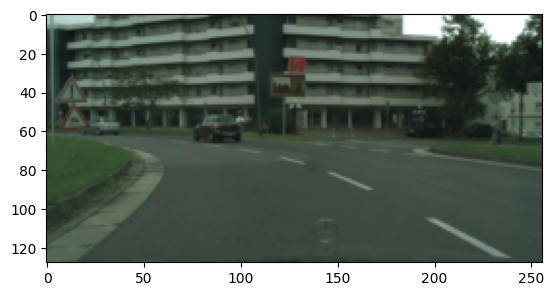

In [22]:
import numpy as np
from matplotlib import pyplot as plt

x = np.load("./data/train/image/0.npy")
x = x*255
x = x.astype(np.uint8)
plt.imshow(x)

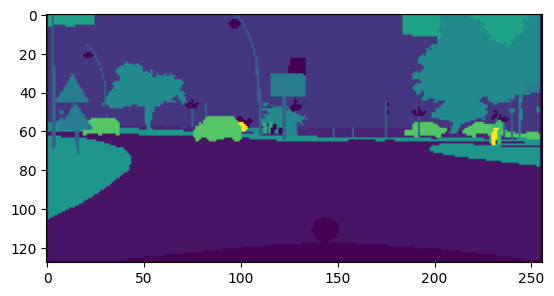

In [2]:
x = np.load("./data/train/label/0.npy")
plt.imshow(x)

In [74]:
import torch
from torch.utils.data import Dataset, DataLoader
from natsort import natsorted
import os 

class CityScapes(Dataset):
    def __init__(self, base_dir, transforms):
        self.base_dir = base_dir
        self.transforms = transforms
        # self.img_dir = f"{self.base_dir}/image"
        self.img_dir = os.path.join(self.base_dir, "image")
        self.label_dir = os.path.join(self.base_dir, "label")
        self.img_names, self.label_names = [], []
        for name in natsorted(os.listdir(self.img_dir)):
            self.img_names.append(name)
        for name in natsorted(os.listdir(self.label_dir)):
            self.label_names.append(name)
    
    def __len__(self):
        return len(self.img_names)
    
    def __getitem__(self, index):
        img_name, label_name = self.img_names[index], self.label_names[index]
        img_path, label_path = os.path.join(self.img_dir, img_name), os.path.join(self.label_dir, label_name)
        img, label = np.load(img_path), np.load(label_path)
        img = (img*255).astype(np.uint8)
        if self.transforms is not None:
            data = self.transforms(image=img, mask=label)
            img, label = data['image'], data['mask']
        label = torch.where(label==13, 1, 0)
        return img, label
train_dataset = CityScapes("./data/train", transforms=train_transforms)
train_dataset[10]

(tensor([[[37, 38, 35,  ..., 26, 25, 26],
          [38, 39, 36,  ..., 25, 25, 25],
          [37, 38, 35,  ..., 25, 26, 25],
          ...,
          [36, 36, 36,  ..., 22, 21, 21],
          [37, 36, 37,  ..., 22, 21, 21],
          [37, 37, 37,  ..., 22, 21, 21]],
 
         [[49, 48, 45,  ..., 37, 37, 37],
          [50, 49, 45,  ..., 36, 36, 36],
          [49, 48, 45,  ..., 36, 38, 36],
          ...,
          [49, 49, 49,  ..., 31, 30, 29],
          [49, 49, 49,  ..., 30, 29, 29],
          [49, 49, 49,  ..., 31, 30, 29]],
 
         [[31, 31, 29,  ..., 25, 25, 25],
          [31, 32, 29,  ..., 25, 24, 25],
          [31, 31, 29,  ..., 25, 25, 25],
          ...,
          [41, 41, 41,  ..., 27, 27, 27],
          [41, 41, 41,  ..., 27, 27, 27],
          [41, 41, 41,  ..., 27, 27, 27]]], dtype=torch.uint8),
 tensor([[0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0],
         ...,
         [0, 0, 0,  ..., 1, 1, 1],
         [0, 0, 0

In [75]:
import albumentations as A
from albumentations.pytorch import ToTensorV2
from torch.utils.data import random_split

train_transforms = A.Compose([
    A.Resize(224, 224),
    A.HorizontalFlip(),
    A.Rotate(limit=10, p=0.5),
    A.RandomBrightnessContrast(p=0.3),
    ToTensorV2()
])
test_transforms = A.Compose([
    A.Resize(224, 224),
    ToTensorV2()
])
train_dataset = CityScapes("./data/train", transforms=train_transforms)
train_dataset, valid_dataset = random_split(train_dataset, (0.9, 0.1))
test_dataset = CityScapes("./data/val", transforms=test_transforms)


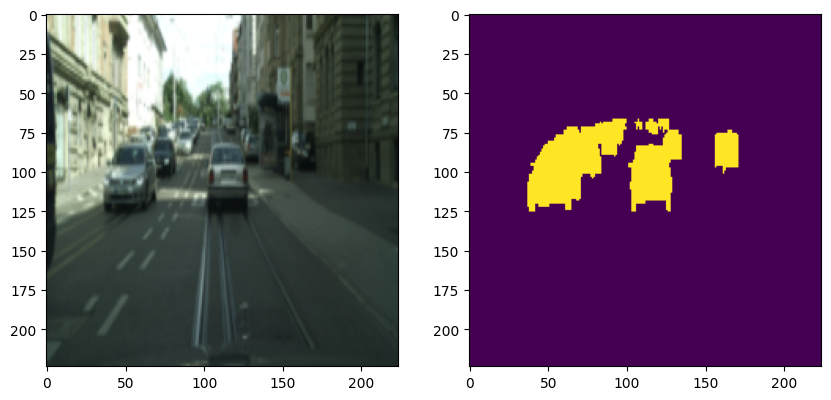

In [43]:
img, label = train_dataset[10]
# plt.imshow(label)
img = img.permute(1,2,0)
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(10,10))
axes[0].imshow(img.cpu().numpy())
axes[1].imshow(label)

In [44]:
import torch.nn as nn

def simple_block(in_channel, out_channel):
    return nn.Sequential(
        nn.Conv2d(in_channel, out_channel, kernel_size=3, stride=1, padding=1),
        nn.BatchNorm2d(out_channel),
        nn.ReLU()
    )

In [61]:
!wget https://download.pytorch.org/models/vgg16_bn-6c64b313.pth

--2025-10-31 12:41:25--  https://download.pytorch.org/models/vgg16_bn-6c64b313.pth
Resolving download.pytorch.org (download.pytorch.org)... 3.164.255.96, 3.164.255.35, 3.164.255.126, ...
Connecting to download.pytorch.org (download.pytorch.org)|3.164.255.96|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 553507836 (528M) [application/octet-stream]
Saving to: ‘vgg16_bn-6c64b313.pth.1’

vgg16_bn-6c64b313.p   6%[>                   ]  34.92M  87.3MB/s               ^C


In [ ]:
encoder = Encoder(3)
encoder.state_dict().keys()
encoder.load_state_dict(weight)
#enc1.0.1.num_batches_tracked

odict_keys(['enc1.0.0.weight', 'enc1.0.0.bias', 'enc1.0.1.weight', 'enc1.0.1.bias', 'enc1.0.1.running_mean', 'enc1.0.1.running_var', 'enc1.0.1.num_batches_tracked', 'enc1.1.0.weight', 'enc1.1.0.bias', 'enc1.1.1.weight', 'enc1.1.1.bias', 'enc1.1.1.running_mean', 'enc1.1.1.running_var', 'enc1.1.1.num_batches_tracked', 'enc2.0.0.weight', 'enc2.0.0.bias', 'enc2.0.1.weight', 'enc2.0.1.bias', 'enc2.0.1.running_mean', 'enc2.0.1.running_var', 'enc2.0.1.num_batches_tracked', 'enc2.1.0.weight', 'enc2.1.0.bias', 'enc2.1.1.weight', 'enc2.1.1.bias', 'enc2.1.1.running_mean', 'enc2.1.1.running_var', 'enc2.1.1.num_batches_tracked', 'enc3.0.0.weight', 'enc3.0.0.bias', 'enc3.0.1.weight', 'enc3.0.1.bias', 'enc3.0.1.running_mean', 'enc3.0.1.running_var', 'enc3.0.1.num_batches_tracked', 'enc3.1.0.weight', 'enc3.1.0.bias', 'enc3.1.1.weight', 'enc3.1.1.bias', 'enc3.1.1.running_mean', 'enc3.1.1.running_var', 'enc3.1.1.num_batches_tracked', 'enc3.2.0.weight', 'enc3.2.0.bias', 'enc3.2.1.weight', 'enc3.2.1.bias'

In [83]:
weight.keys()

odict_keys(['features.0.weight', 'features.0.bias', 'features.1.weight', 'features.1.bias', 'features.1.running_mean', 'features.1.running_var', 'features.3.weight', 'features.3.bias', 'features.4.weight', 'features.4.bias', 'features.4.running_mean', 'features.4.running_var', 'features.7.weight', 'features.7.bias', 'features.8.weight', 'features.8.bias', 'features.8.running_mean', 'features.8.running_var', 'features.10.weight', 'features.10.bias', 'features.11.weight', 'features.11.bias', 'features.11.running_mean', 'features.11.running_var', 'features.14.weight', 'features.14.bias', 'features.15.weight', 'features.15.bias', 'features.15.running_mean', 'features.15.running_var', 'features.17.weight', 'features.17.bias', 'features.18.weight', 'features.18.bias', 'features.18.running_mean', 'features.18.running_var', 'features.20.weight', 'features.20.bias', 'features.21.weight', 'features.21.bias', 'features.21.running_mean', 'features.21.running_var', 'features.24.weight', 'features.2

In [85]:
weight = torch.load("./vgg16_bn-6c64b313.pth")
# for item in weight.items():
#     print(item[0], item[1].shape)

In [46]:
import torch.nn.functional as F

class Encoder(nn.Module):
    def __init__(self, in_channel=3):
        super().__init__()
        self.in_channel = in_channel
        self.enc1 = nn.Sequential(
                        simple_block(3, 64),
                        simple_block(64, 64)
                        )
        self.enc2 = nn.Sequential(
                        simple_block(64, 128),
                        simple_block(128, 128)
                        )
        self.enc3 = nn.Sequential(
                        simple_block(128, 256),
                        simple_block(256, 256),
                        simple_block(256, 256),
                        )
        self.enc4 = nn.Sequential(
                        simple_block(256, 512),
                        simple_block(512, 512),
                        simple_block(512, 512),
                        )
        self.enc5 = nn.Sequential(
                        simple_block(512, 512),
                        simple_block(512, 512),
                        simple_block(512, 512),
                        )
        
    def forward(self, x):
        x, ind1 = F.max_pool2d(self.enc1(x), kernel_size=2, stride=2, return_indices=True)
        x, ind2 = F.max_pool2d(self.enc2(x), kernel_size=2, stride=2, return_indices=True)
        x, ind3 = F.max_pool2d(self.enc3(x), kernel_size=2, stride=2, return_indices=True)
        x, ind4 = F.max_pool2d(self.enc4(x), kernel_size=2, stride=2, return_indices=True)
        x, ind5 = F.max_pool2d(self.enc5(x), kernel_size=2, stride=2, return_indices=True)
        return x, [ind1, ind2, ind3, ind4, ind5]
        # call max_pool
        

In [66]:
class Decoder(nn.Module):
    def __init__(self, out_channel=3):
        super().__init__()
        self.out_channel = out_channel
        self.dec1 = nn.Sequential(
                        simple_block(512, 512),
                        simple_block(512, 512),
                        simple_block(512, 512),
                        )
        
        self.dec2 = nn.Sequential(
                        simple_block(512, 512),
                        simple_block(512, 512),
                        simple_block(512, 256),
                        )
        self.dec3 = nn.Sequential(
                        simple_block(256, 256),
                        simple_block(256, 256),
                        simple_block(256, 128),
                        )
        self.dec4 =  nn.Sequential(
                        simple_block(128, 128),
                        simple_block(128, 64)
                        )
        self.dec5 = nn.Sequential(
                        simple_block(64, 64),
                        nn.Conv2d(64, out_channel, 3, 1, 1)
                        )
    def forward(self, x, inds):
        x = F.max_unpool2d(x, indices=inds[-1], kernel_size=2, stride=2)
        x = F.max_unpool2d(self.dec1(x), indices=inds[-2], kernel_size=2, stride=2)
        x = F.max_unpool2d(self.dec2(x), indices=inds[-3], kernel_size=2, stride=2)
        x = F.max_unpool2d(self.dec3(x), indices=inds[-4], kernel_size=2, stride=2)
        x = F.max_unpool2d(self.dec4(x), indices=inds[-5], kernel_size=2, stride=2)
        x = self.dec5(x)
        return x

In [ ]:
class SegNet(nn.Module):
    def __init__(self, in_channel=3, out_channel=2):
        super().__init__()
        self.encoder = self.load_weight_from_VGG16(in_channel)
        self.decoder = Decoder(out_channel=out_channel)
        
    def load_weight_from_VGG16(self, in_channel):
        encoder = Encoder(in_channel=in_channel)
        vgg_weight = torch.load("./vgg16_bn-6c64b313.pth")
        new_weights = []
        for key, value in vgg_weight.items():
            if "classifier" in key:
                continue
            new_weights.append(value)
        
        new_names = []
        for key in encoder.state_dict():
            if "num_batches_tracked" in key:
                continue
            new_names.append(key)
        
        new_state_dict = {}
        for n, w in zip(new_names, new_weights):
            new_state_dict[n] = w
        encoder.load_state_dict(new_state_dict)            
        
        return encoder
    
    def forward(self, x):
        x, idxs = self.encoder(x)
        x = self.decoder(x, idxs)
        return x
model = SegNet(3, 2)

In [97]:
train_dataloader = DataLoader(train_dataset, batch_size=32, shuffle=True)
valid_dataloader = DataLoader(valid_dataset, batch_size=32, shuffle=False)
test_dataloader = DataLoader(test_dataset, batch_size=32, shuffle=False)

dataloaders = {'train': train_dataloader, 'valid': valid_dataloader, 'test': test_dataloader}

In [98]:
from torch.optim import SGD

model = SegNet(3, 2)
optimizer = SGD(model.parameters(), lr=0.01, momentum=0.9)
device = 'cuda' if torch.cuda.is_available() else 'cpu'
model.to(device)
loss = torch.nn.CrossEntropyLoss()

In [99]:
class AverageMeter(object):
    """Computes and stores the average and current value"""
    def __init__(self):
        self.reset()

    def reset(self):
        self.val = 0
        self.avg = 0
        self.sum = 0
        self.count = 0

    def update(self, val, n=1):
        if val != np.nan and val != np.inf:
            self.val = val
            self.sum += val * n
            self.count += n
            self.avg = self.sum / self.count

In [100]:
def calculate_miou(pred, gt, range_of_classes):
    ious = []
    for class_idx in range(range_of_classes):
        pred_ = (pred==class_idx)
        gt_ = (gt==class_idx)

        intersection = (pred_ & gt_).sum().item()
        union = (pred_ | gt_).sum().item()

        if union < 1e-10:
            continue
        else:
            ious.append(intersection/union)
    return np.array(ious).mean()



In [101]:
from tqdm import tqdm

def train(model, optimizer, criterion, dataloaders, num_of_epochs):
    for epoch in range(num_of_epochs):
        for phase in ['train', 'valid']:
            loss_total = AverageMeter()
            miou_total = AverageMeter()
            if phase == 'train':
                model.train()
            else:
                model.eval()
            with tqdm(dataloaders[phase]) as pbar:
                for img, label in pbar:
                    # print(img)
                    img, label = img.to(device), label.to(device)
                    optimizer.zero_grad()
                    with torch.set_grad_enabled(phase=='train'):
                        output = model(img.float())
                        loss = criterion(output, label)
                        if phase == 'train':
                            loss.backward()
                            optimizer.step()
                    loss_total.update(loss.item(), img.shape[0])
                    miou = calculate_miou(output.argmax(1), label, 2)
                    miou_total.update(miou, img.shape[0])
                    pbar.set_postfix(Loss=f"{loss_total.avg:.4f}", MIoU=f"{miou_total.avg:.4f}")
            print(f"{phase} Epoch {epoch} Loss: {loss_total.avg} IoU: {miou_total.avg}")


In [105]:
train(model, optimizer, loss, dataloaders, 10)

100%|██████████| 84/84 [00:25<00:00,  3.24it/s, Loss=0.0545, MIoU=0.8391]


train Epoch 0 Loss: 0.05446848541197713 IoU: 0.839135141437277


100%|██████████| 10/10 [00:01<00:00,  8.93it/s, Loss=0.0613, MIoU=0.8366]

valid Epoch 0 Loss: 0.061330556142009066 IoU: 0.8366192141614147


In [103]:
from tqdm import tqdm

def test(model, optimizer, criterion, dataloaders):
    for phase in ['test']:
        loss_total = AverageMeter()
        miou_total = AverageMeter()
        model.eval()
        with tqdm(dataloaders[phase]) as pbar:
            for img, label in pbar:
                img, label = img.to(device), label.to(device)
                optimizer.zero_grad()
                with torch.set_grad_enabled(phase=='train'):
                    output = model(img.float())
                    loss = criterion(output, label)
                loss_total.update(loss.item(), img.shape[0])
                miou = calculate_miou(output.argmax(1), label, 2)
                miou_total.update(miou, img.shape[0])
                pbar.set_postfix(Loss=f"{loss_total.avg:.4f}", MIoU=f"{miou_total.avg:.4f}")
    print('miou', miou_total.avg)


In [104]:
test(model, optimizer, loss, dataloaders)

100%|██████████| 16/16 [00:01<00:00,  9.07it/s, Loss=0.0685, MIoU=0.8030]

miou 0.8030471250407554


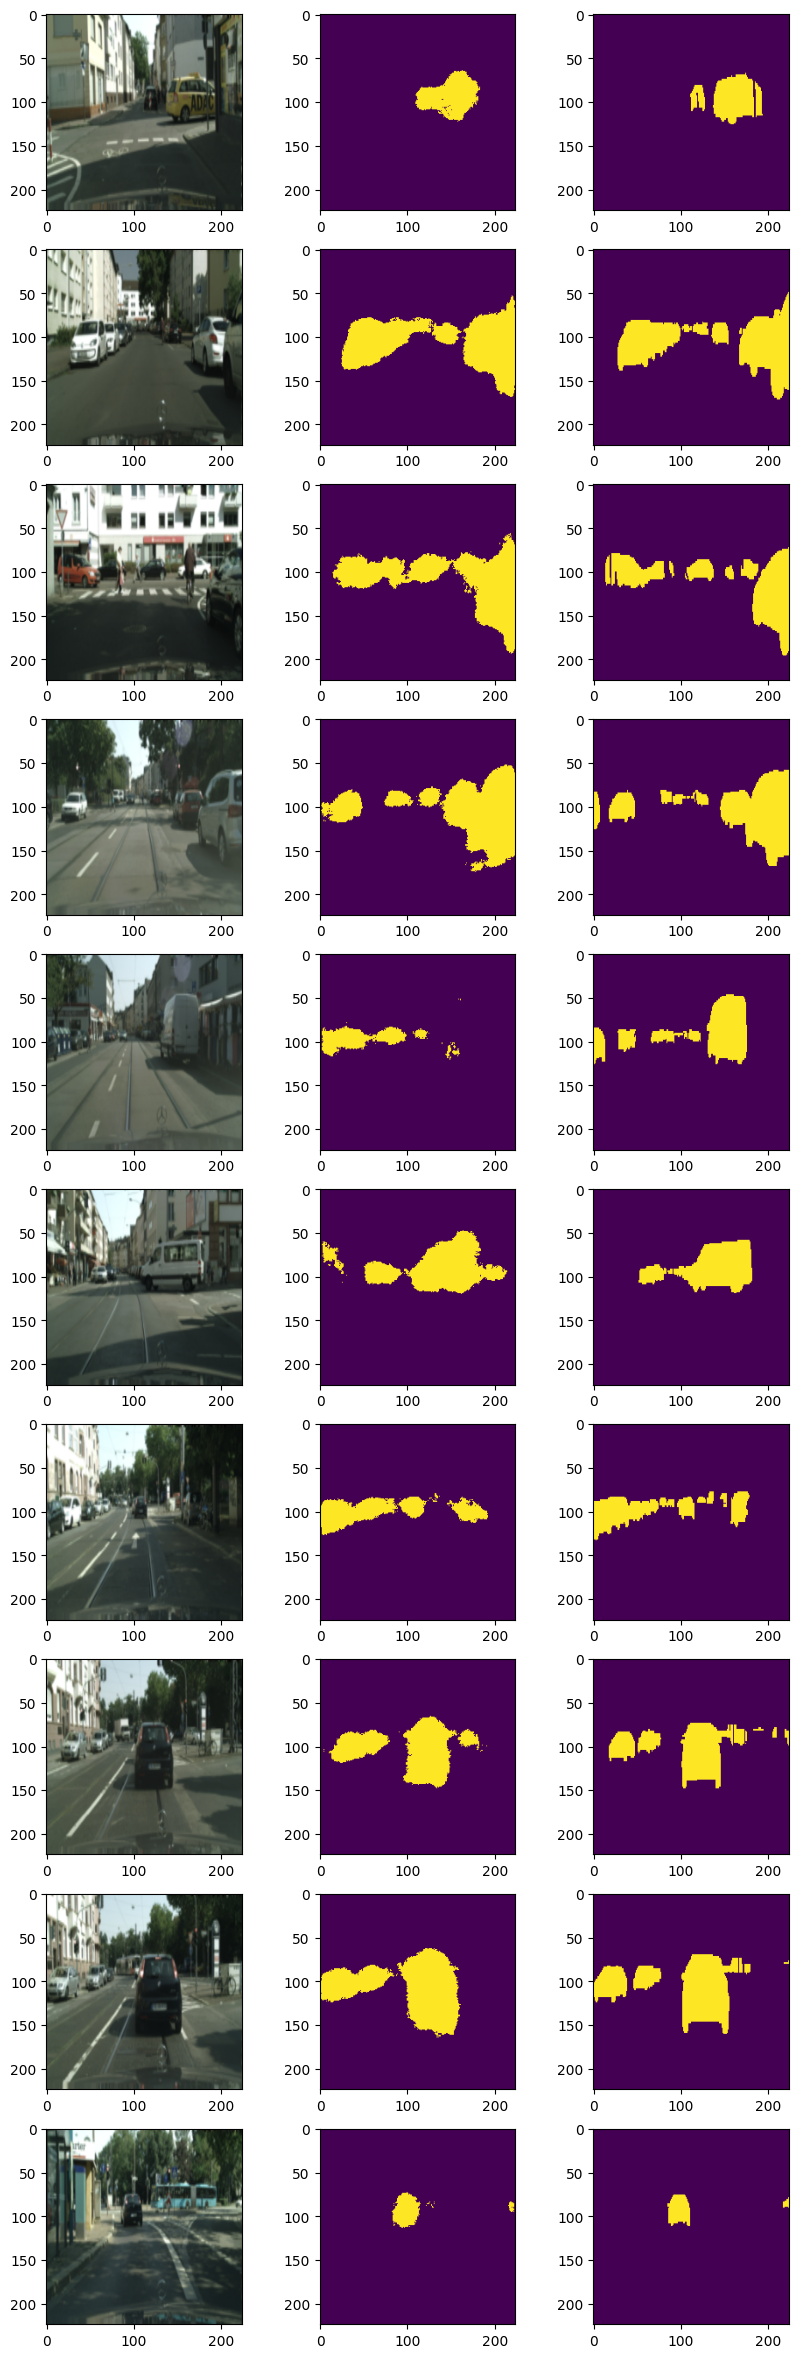

In [ ]:
fig, axes = plt.subplots(nrows=10, ncols=3, figsize=(10, 30))
cnt = 0

data, label = next(iter(test_dataloader))
data = data.to(device)
output = model(data.float())
for i in range(10):
        img = data[i] / 255
        mask = output.argmax(1)[i].cpu().numpy()
        mask = mask.astype(np.int8)
        gt = label[i].cpu().numpy()
        gt = gt.astype(np.int8)
        img = img.permute(1,2,0)*255
        img = img.cpu().numpy().astype(np.uint8)
        axes[i, 0].imshow(img)
        axes[i,1].imshow(mask)
        axes[i,2].imshow(gt)